# Exploratory Data Analysis — Real Estate Valuation

Before any modeling, this notebook answers four questions about the
[UCI Real Estate Valuation dataset](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set):

1. What does each variable look like on its own?
2. How does each feature relate to the target (price per unit area)?
3. Which features overlap with each other?
4. Are there outliers or quality issues to handle?

Every finding here feeds a concrete decision in the feature pipeline
(`src/house_prices/features.py`). The data itself is loaded through the same
`house_prices.data` module the rest of the project uses, so the notebook and
the training code can never disagree about what the dataset contains.

A note on units: the target is the house price of unit area, measured in
**10,000 New Taiwan Dollars per ping** (1 ping = 3.3 m²). A value of 40 means
400,000 TWD per ping.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from house_prices import config
from house_prices.data import load_dataset

sns.set_theme(style="whitegrid", context="notebook")

FIGURES_DIR = config.REPORTS_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Export a chart so the README and the presentation can reuse it."""
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


df = load_dataset()
df.head()

,transaction_date,house_age_years,mrt_distance_m,n_convenience_stores,latitude,longitude,price_per_unit_area
No,,,,,,,
1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


## 1. Overview

414 transactions, six features, one target. `load_dataset()` has already
validated the schema: correct columns, numeric types, no missing values,
every value inside its documented range.

In [2]:
print(f"{df.shape[0]} rows, {df.shape[1]} columns, {int(df.isna().sum().sum())} missing values")
df.describe().T.round(2)

414 rows, 7 columns, 0 missing values


,count,mean,std,min,25%,50%,75%,max
transaction_date,414.0,2013.15,0.28,2012.67,2012.92,2013.17,2013.42,2013.58
house_age_years,414.0,17.71,11.39,0.00,9.02,16.10,28.15,43.80
mrt_distance_m,414.0,1083.89,1262.11,23.38,289.32,492.23,1454.28,6488.02
n_convenience_stores,414.0,4.09,2.95,0.00,1.00,4.00,6.00,10.00
latitude,414.0,24.97,0.01,24.93,24.96,24.97,24.98,25.01
longitude,414.0,121.53,0.02,121.47,121.53,121.54,121.54,121.57
price_per_unit_area,414.0,37.98,13.61,7.60,27.70,38.45,46.60,117.50


The summary table already hints at the two stories of this dataset. Prices
run from 7.6 to 117.5 with a mean around 38. Distance to the nearest MRT
station runs from 23 m to 6,488 m, but its mean (1,084 m) sits far above its
median (492 m) — a classic sign of right skew that we confirm below.

## 2. The target

Prices are moderately right-skewed (skewness 0.60): most houses sit between
20 and 55, with a thinner tail of expensive ones and a single extreme point
at 117.5 that section 6 examines.

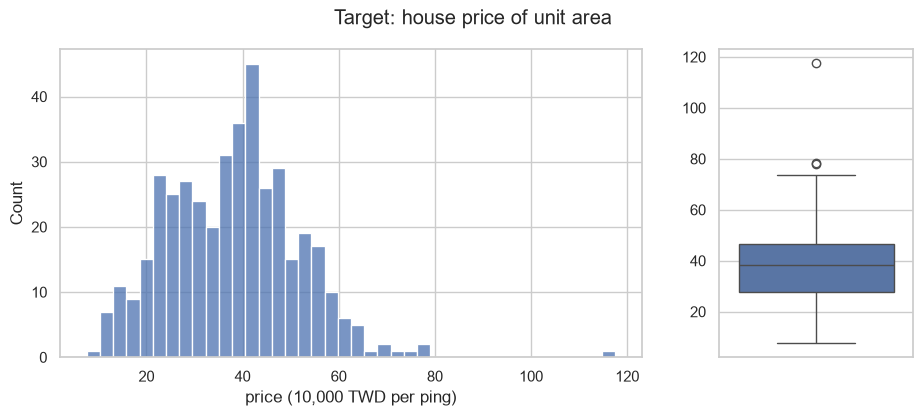

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), width_ratios=[3, 1])
sns.histplot(df[config.TARGET_COLUMN], bins=40, ax=axes[0])
axes[0].set_xlabel("price (10,000 TWD per ping)")
sns.boxplot(y=df[config.TARGET_COLUMN], ax=axes[1])
axes[1].set_ylabel("")
fig.suptitle("Target: house price of unit area")
save_fig(fig, "eda_target_distribution")
plt.show()

## 3. Feature distributions

The histogram grid below is where the feature-engineering plan starts.

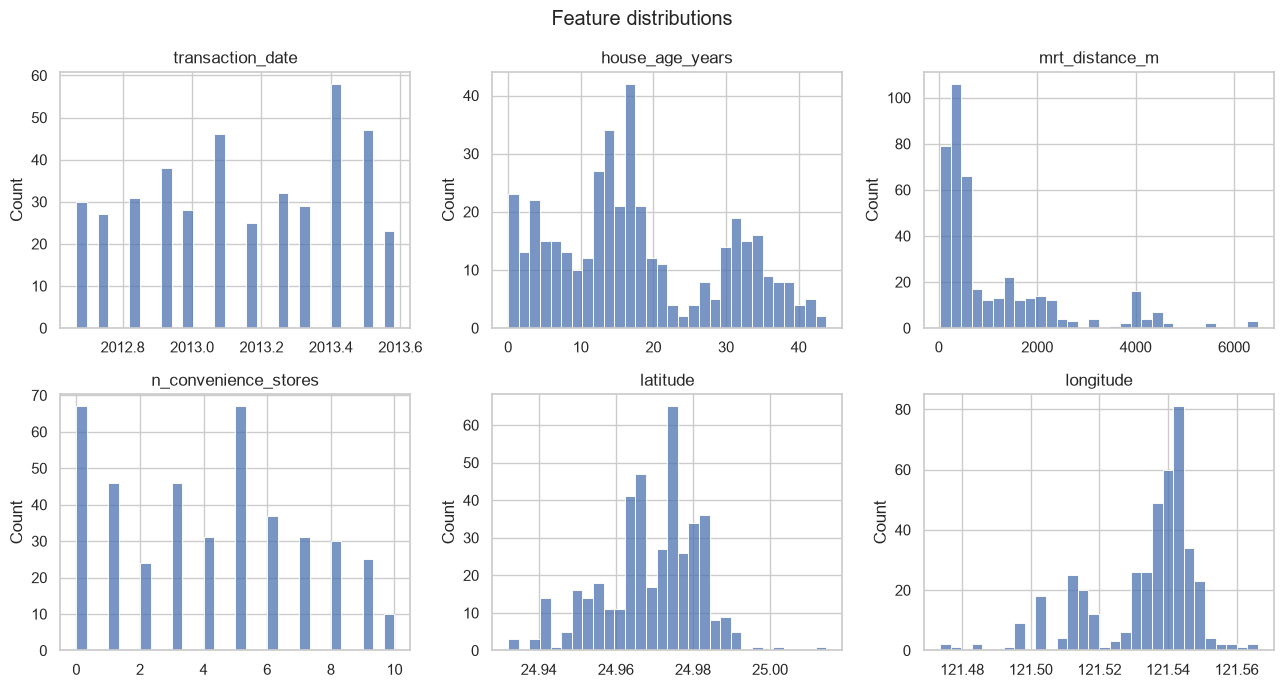

,skewness
mrt_distance_m,1.89
house_age_years,0.38
n_convenience_stores,0.15
transaction_date,-0.15
latitude,-0.44
longitude,-1.22


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, config.FEATURE_COLUMNS):
    sns.histplot(df[col], bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Feature distributions")
fig.tight_layout()
save_fig(fig, "eda_feature_distributions")
plt.show()

df[config.FEATURE_COLUMNS].skew().round(2).sort_values(ascending=False).to_frame("skewness")

Observations, in order of importance:

- **`mrt_distance_m` is heavily right-skewed** (skewness 1.89). Half the
  houses are within 492 m of a station, three quarters within 1,454 m, and a
  long tail stretches to 6,488 m. A linear model fed the raw values would let
  that tail dominate. This is the strongest argument for a log transform,
  tested in section 4.
- `house_age_years` is bimodal: a large group of nearly new houses (0–10
  years) and another wave around 30–40 years. Age clearly does not act on
  price as a simple straight line; section 5 quantifies that.
- `n_convenience_stores` is a small integer count (0–10), roughly uniform.
- `transaction_date` covers only 12 months (2012.67–2013.58), so it can
  carry at most a mild market drift.
- `latitude`/`longitude` concentrate in the dense urban core with thin
  edges — they describe *where*, and section 7 shows that geography is the
  price map itself.

## 4. Each feature against price

Two things to look for below: the *direction* of each relationship, and
whether it is straight enough for a linear model.

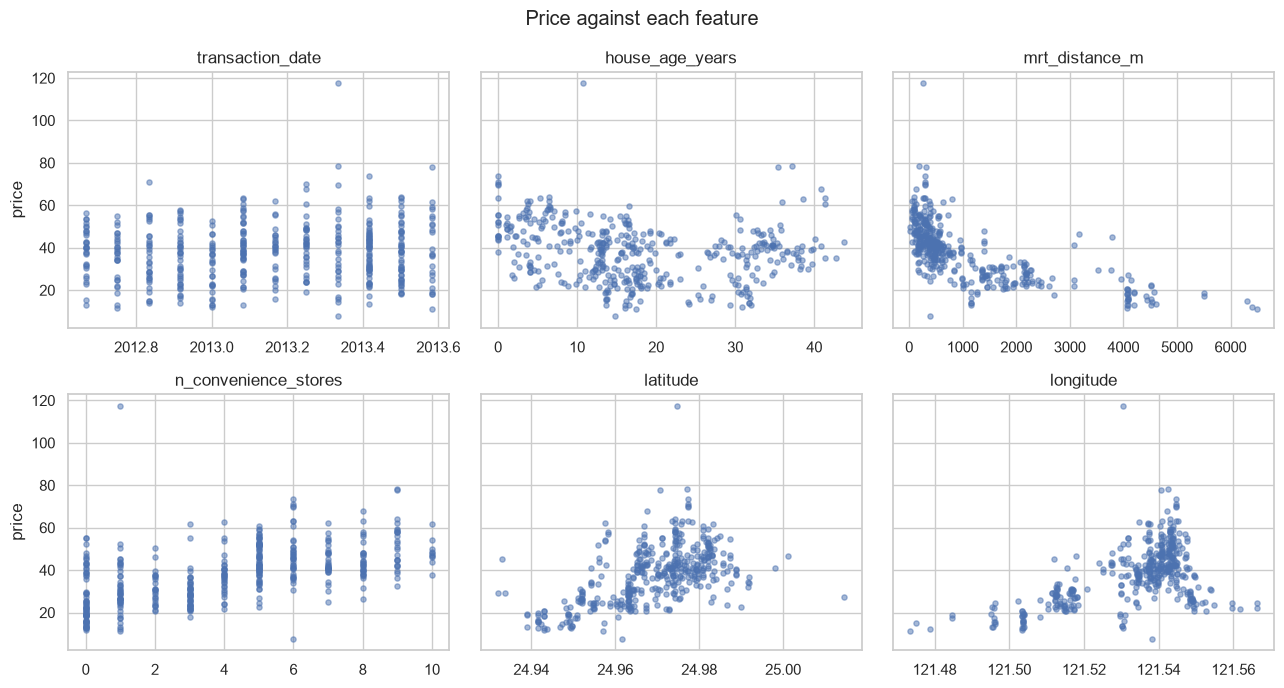

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, col in zip(axes.flat, config.FEATURE_COLUMNS):
    ax.scatter(df[col], df[config.TARGET_COLUMN], s=14, alpha=0.5)
    ax.set_title(col)
for row in axes:
    row[0].set_ylabel("price")
fig.suptitle("Price against each feature")
fig.tight_layout()
save_fig(fig, "eda_price_vs_features")
plt.show()

The MRT panel shows a steep price drop over the first few hundred meters that
flattens with distance — a curve, not a line. Compressing distance with a log
makes the relationship close to linear, and the correlation strengthens from
−0.67 to −0.73:

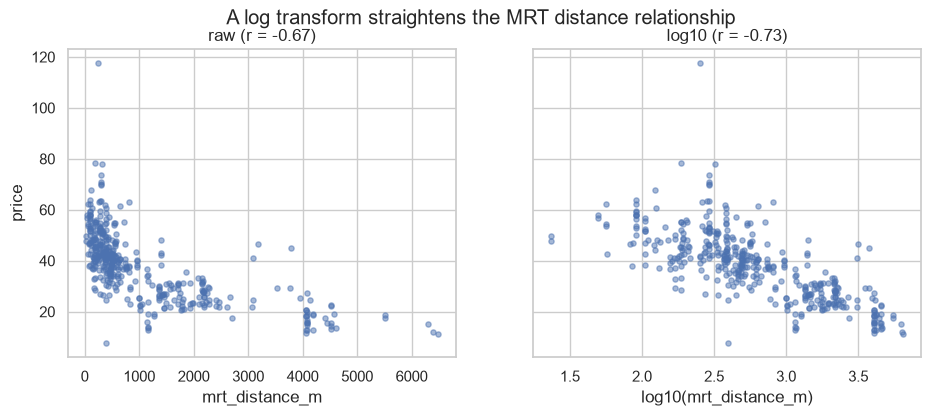

In [ ]:
log_mrt = np.log10(df["mrt_distance_m"])
r_raw = df["mrt_distance_m"].corr(df[config.TARGET_COLUMN])
r_log = log_mrt.corr(df[config.TARGET_COLUMN])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].scatter(df["mrt_distance_m"], df[config.TARGET_COLUMN], s=14, alpha=0.5)
axes[0].set(xlabel="mrt_distance_m", ylabel="price", title=f"raw (r = {r_raw:.2f})")
axes[1].scatter(log_mrt, df[config.TARGET_COLUMN], s=14, alpha=0.5)
axes[1].set(xlabel="log10(mrt_distance_m)", title=f"log10 (r = {r_log:.2f})")
fig.suptitle("A log transform straightens the MRT distance relationship")
save_fig(fig, "eda_mrt_log_transform")
plt.show()

This is the intuition behind the transform: for a buyer, the difference
between living 100 m and 600 m from a station is enormous; the difference
between 4,000 m and 4,500 m is barely noticeable. The log scale encodes
exactly that.

**Decision for the pipeline: model `log(mrt_distance_m)`, not the raw value.**

## 5. House age is not a straight line

The scatter above already suggested it; average price by age decade confirms
it. Prices fall through the first three decades, then *rebound* for houses
past 40 — plausibly renovated properties or locations where land value
dominates the building's age.

In [ ]:
df.groupby(df["house_age_years"] // 10 * 10)[config.TARGET_COLUMN].agg(["mean", "count"]).round(1)

,mean,count
house_age_years,,
0.0,46.6,109
10.0,34.2,167
20.0,31.3,43
30.0,36.6,87
40.0,48.8,8


A single linear coefficient cannot express "down, then up". Tree-based models
handle such shapes natively, which is one reason they are on the model
candidate list alongside linear baselines.

**Decision for the pipeline: keep `house_age_years`; expect tree models (or a
polynomial term) to use it better than a plain linear fit.**

## 6. Correlations and feature overlap

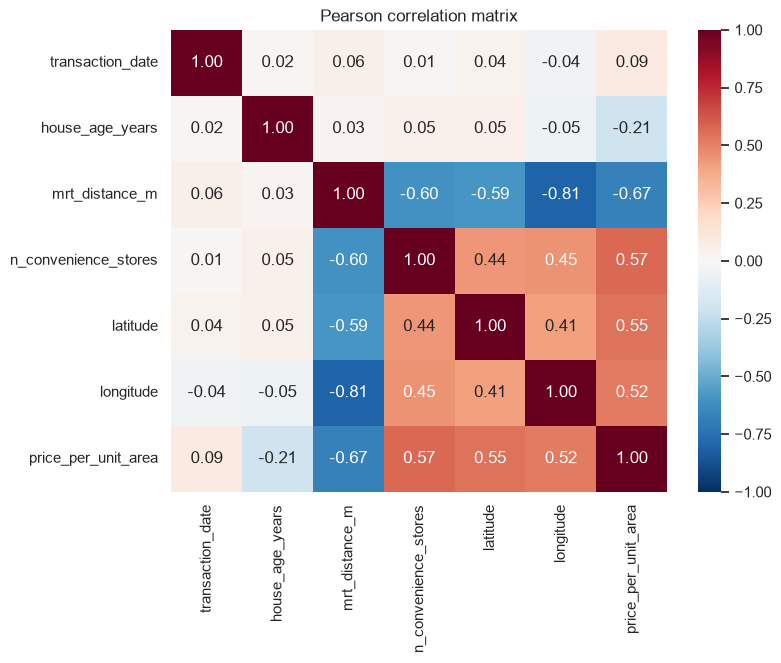

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation matrix")
save_fig(fig, "eda_correlations")
plt.show()

Reading the last row (correlation with price):

| feature | r | reading |
|---|---|---|
| `mrt_distance_m` | −0.67 | strongest single predictor (−0.73 after log) |
| `n_convenience_stores` | +0.57 | more stores, higher price |
| `latitude` | +0.55 | north = closer to the urban core here |
| `longitude` | +0.52 | same story east–west |
| `house_age_years` | −0.21 | weak *linearly* — the U-shape hides its value |
| `transaction_date` | +0.09 | negligible |

Just as important is the overlap *between* features: MRT distance correlates
with longitude at **−0.81**, with convenience stores at −0.60 and latitude at
−0.59. All four are partly measuring the same thing — how central the
location is. That redundancy is exactly what regularization (Ridge/Lasso) is
for, and it means individual coefficient values should be interpreted with
care when we fit the linear models.

`transaction_date` earns a place on the exclusion shortlist twice over: it
carries almost no signal (r = 0.09), and a deployed model cannot receive a
meaningful "transaction date from 2013" for a prediction made today. The modeling phase
tests dropping it.

## 7. Geography is the price map

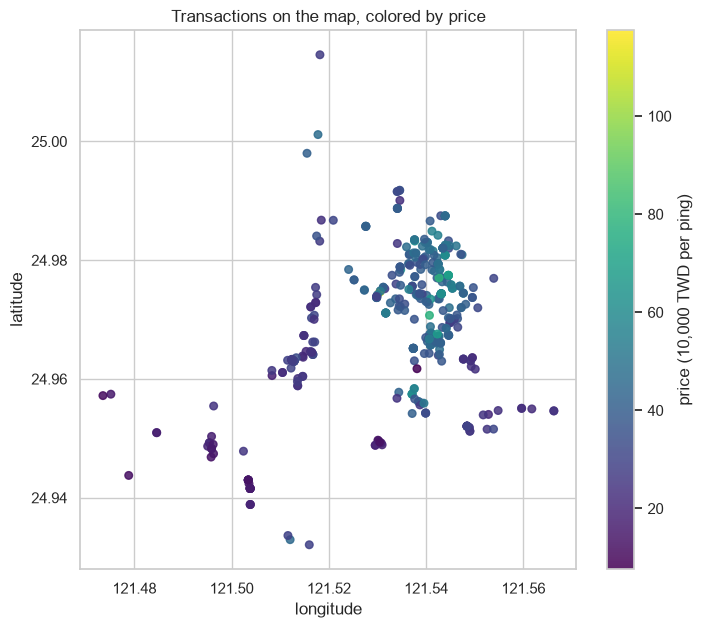

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(df["longitude"], df["latitude"], c=df[config.TARGET_COLUMN],
                cmap="viridis", s=30, alpha=0.85)
fig.colorbar(sc, label="price (10,000 TWD per ping)")
ax.set(xlabel="longitude", ylabel="latitude",
       title="Transactions on the map, colored by price")
save_fig(fig, "eda_geography")
plt.show()

Expensive houses (yellow) cluster tightly in the dense center; prices fade
outward in every direction. Latitude and longitude are individually crude
predictors, but *together* they encode neighborhood — a tree model can carve
this map into price regions with a handful of splits. Linear models will get
a derived distance-from-center feature in the pipeline so they can use
location too.

## 8. Outliers

In [ ]:
df.nlargest(5, config.TARGET_COLUMN)

,transaction_date,house_age_years,mrt_distance_m,n_convenience_stores,latitude,longitude,price_per_unit_area
No,,,,,,,
271,2013.333333,10.8,252.5822,1,24.97460,121.53046,117.5
221,2013.333333,37.2,186.5101,9,24.97703,121.54265,78.3
313,2013.583333,35.4,318.5292,9,24.97071,121.54069,78.0
167,2013.416667,0.0,292.9978,6,24.97744,121.54458,73.6
106,2012.833333,0.0,292.9978,6,24.97744,121.54458,71.0


One transaction stands alone: 117.5 — fifty percent above the runner-up
(78.3). It is a 10.8-year-old house 253 m from a station in the city core, so
the *direction* is right; only the magnitude is extreme. It may be a luxury
property or a data-entry error; the dataset offers no way to tell.

**Decision: keep the row** (with 414 rows, deleting data on suspicion is a
worse trade than keeping one extreme point), but report MAE alongside RMSE in
evaluation — RMSE squares errors, so this single point can dominate it, while
MAE stays robust. If the test split happens to contain this row, residual
plots will make its effect visible.

## 9. Findings → modeling decisions

| # | Finding | Decision for modeling |
|---|---|---|
| 1 | `mrt_distance_m` skewed (1.89), relationship log-shaped | log-transform it (r: −0.67 → −0.73) |
| 2 | Feature scales differ by orders of magnitude | standardize inside the pipeline for linear models |
| 3 | `house_age_years` is U-shaped, not linear | keep it; rely on trees / consider a squared term |
| 4 | Heavy feature overlap (MRT ↔ longitude r = −0.81) | use Ridge/Lasso; read coefficients with care |
| 5 | `latitude`+`longitude` jointly encode neighborhood | keep both; add distance-from-center for linear models |
| 6 | `transaction_date` weak (r = 0.09) and unavailable at inference time | test excluding it |
| 7 | One extreme price (117.5), plausibly legitimate | keep; report MAE next to RMSE |
| 8 | No missing values, all ranges valid | no imputation needed |